

## Residency-2: Project-2 | Statistical Learning | Jayant Ojha

In [2]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [25]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_1samp, ttest_ind, mannwhitneyu, levene, shapiro
from statsmodels.stats.power import ttest_power
from scipy import stats

###  Import data

In [4]:
#Store data from external csv to an initial datframe variable
df1 = pd.read_csv("./data.csv")

In [5]:
#Observe the original data
df1.head()
#have the proper float format
pd.options.display.float_format = '{:,.2f}'.format
#convert to thousands
df1["Old Scheme"] = 1000*df1["Old Scheme (in thousands)"]
df1["New Scheme"] = 1000*df1["New Scheme (in thousands)"]

,SALESPERSON,Old Scheme (in thousands),New Scheme (in thousands)
0,1,57,62
1,2,103,122
2,3,59,54
3,4,75,82
4,5,84,84


In [6]:
#Get the altogether new dataframe with changed format etc.
df = df1.loc[:,["SALESPERSON", "Old Scheme", "New Scheme"]]
df.head()

,SALESPERSON,Old Scheme,New Scheme
0,1,57000,62000
1,2,103000,122000
2,3,59000,54000
3,4,75000,82000
4,5,84000,84000


### Q1. Find the mean of old scheme and new scheme column. 

In [7]:
#mean for the "old & new scheme columns"
df_mean = df.loc[:, df.columns != "SALESPERSON"].mean().to_frame()
df_mean.columns = ["mean"]
df_mean

,mean
Old Scheme,"68,033.33"
New Scheme,"72,033.33"


### Q2. Use the five percent significance test over the data to determine the p value, to check new scheme has significantly raised outputs?

In [8]:
#First as the question is related to "raise/increase" of the mean, and the population std. dev. is not known
#we will be inclined to apply the one-tailed t-test (paired), we can addiitonally use the histograms and shapiro
#test to find if the data-groups are sufficiently "normal" before going for a t-test.
# Seperating data into 2 groups
old_scheme = df["Old Scheme"]
new_scheme = df["New Scheme"]

In [9]:
# For checking Normality distribution of each distribution
# Null Hypothesis: Distribution is Normal
#p-value -> 0.9813658595085144
shapiro(old_scheme)

(0.9885101914405823, 0.9813658595085144)

In [10]:
# For checking Normality distribution of each distribution
# Null Hypothesis: Distribution is Normal
##p-value -> 0.5057420134544373
shapiro(new_scheme)

(0.9687567353248596, 0.5057420134544373)

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt 
%matplotlib inline

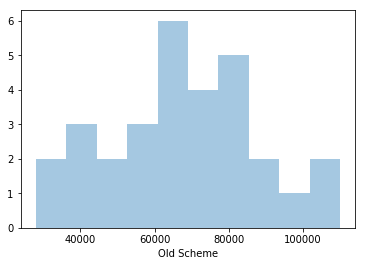

In [12]:
sns.distplot(old_scheme, bins=10, kde=False);

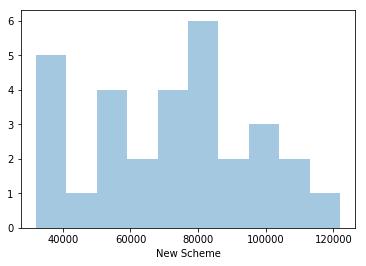

In [13]:
sns.distplot(new_scheme, bins=10, kde=False);

In [16]:
# paired t-test: doing two measurments on the same experimental unit
#H0: (μ_new_scheme - μ_old_scheme) = 0 
#Ha: (μ_new_scheme - μ_old_scheme) > 0  [i.e. the new scheme has enabled a higher mean than the older scheme]
t_statistic, p_value = ttest_1samp(new_scheme-old_scheme, 0)
print(t_statistic, p_value)
print("real_p_val = {}".format(p_value/2))#the ttest_1samp does a 2-tailed, while here a 1-tailed is desired, hence /2.
# (https://stackoverflow.com/questions/15984221/how-to-perform-two-sample-one-tailed-t-test-with-numpy-scipy)

1.5559143823544377 0.13057553961337662
real_p_val = 0.06528776980668831


### Q3. What conclusion does the test (p-value) lead to?

In [14]:
#as the real p_value = 0.0652 > α (0.05)....=> the null hypothesis is NOT rejected, i.e. the alternative 
# one: (μ_new_scheme - μ_old_scheme) > 0 is NOT true ....thus the new scheme did NOT raise the outputs by
#significant amount.

### Q-4a. Suppose it has been calculated that in order for Titan to break even, the average output must increase by £5000 in the scheme compared to the old scheme. If this figure is alternative hypothesis, what is the probability of a type 1 error?

In [15]:
# as we are using the "five percent" significance test over the data, the probability of a type 1 eror = 5%.

### Q-4b. Suppose it has been calculated that in order for Titan to break even, the average output must increase by £5000 in the scheme compared to the old scheme. If this figure is alternative hypothesis, what is the p- value of the hypothesis test if we test for a difference of $5000 ?

In [16]:
# paired t-test: doing two measurments on the same experimental unit
#H0: (μ_new_scheme - μ_old_scheme) = 5000 
#Ha: (μ_new_scheme - μ_old_scheme) > 5000  
t_statistic, p_value = ttest_1samp(new_scheme - old_scheme, 5000)
print(t_statistic, p_value)
print("real_p_val = {}".format(p_value/2))#the ttest_1samp does a 2-tailed, while here a 1-tailed is desired, hence /2
#Thus the p_value of the hypothesis test if we test for a difference of $5000 is = 0.3500667456306643

-0.3889785955886094 0.7001334912613286
real_p_val = 0.3500667456306643


### Q-4c. Suppose it has been calculated that in order for Titan to break even, the average output must increase by £5000 in the scheme compared to the old scheme. If this figure is alternative hypothesis, what is Power of the test

In [31]:
#the question says: what if,the difference this new scheme made was actually/truly: $5000 (i.e. with the true value as 
# μd = 5000, what is the probability of commiting the type 2 error, in case we do not reject the earlier 
# hypothesis Ho: (μ_new_scheme - μ_old_scheme) = 0 & Ha: (μ_new_scheme - μ_old_scheme) > 0 
#since β = P (Do not reject H0 | H0 is false, due to the fact that it actually is 5000)
#The t_critical at the 0.05 significance level for the degree of freedom =29 is t_critical = 1.699127
#thus the H0 is not rejected upto x_bar = μ + t_critical * SE [here μ = 0, t_critical = 1.699127,
# SE = np.std(new_scheme - old_scheme)/ np.sqrt(30)] 

x_bar =  0 + 1.699127*np.std(new_scheme - old_scheme)/ np.sqrt(30)
print(x_bar)
#thus the H0 is not rejected upto x_bar= 4294.756
#=> β = P (Do not reject H0 | μd=5000)
#     = P(x_bar < 4294.756 | μd = 5000)
#     Now in terms of normalized standard t form w..r.t the μd = 5000, 
#     t = (4294.756-5000)/np.std(new_scheme - old_scheme)/ np.sqrt(30)
t=(4294.756-5000)/(np.std(new_scheme - old_scheme)/ np.sqrt(30))
print(t)
#Thus, β = P (Do not reject H0 | μd=5000) = P(x_bar < 4294.756 | μd = 5000) = P (t < -0.279014 | μd = 5000)
#= P (t < -0.279014 | μd = 5000)


β = stats.t.cdf(t,df=29)
print(β)

print ("power of test = {}".format(1-β))

4294.756134874993
-0.2790144735477229
0.39110692968937283
power of test = 0.6088930703106272


# End Of Assignment